## 1. 🏗️ Construction du pipeline EDS-NLP
Chargement et configuration du pipeline médical avec les composants 
de segmentation, normalisation, détection de dates et matching de termes cliniques.



In [13]:

print("✅ Pipeline EDS-NLP chargé avec succès !")


✅ Pipeline EDS-NLP chargé avec succès !


## 2. 🔍 Extraction des entités médicales
Analyse du texte clinique et identification des entités nommées 
(symptômes, pathologies) par spécialité médicale.


In [14]:
# Texte médical de test
texte = """
Le patient Jean Dupont, né le 12/03/1965, consulte le 20/01/2024 
pour des douleurs thoraciques depuis 3 jours. 
Il présente également de la fièvre à 38.5°C.
Antécédents : insuffisance cardiaque diagnostiquée en 2020.
"""

# # On analyse le texte avec notre pipeline
# doc = nlp(texte)

# # On affiche les entités détectées
# print("📋 Entités détectées :")
# for ent in doc.ents:
#     print(f"  → '{ent.text}' | Type : {ent.label_}")

print("⚠️ Détection EDS-NLP désactivée — texte de test chargé ✅")

⚠️ Détection EDS-NLP désactivée — texte de test chargé ✅


## 3. 🔒 Anonymisation des données sensibles
Masquage des informations personnelles (noms, dates) à l'aide de spaCy 
et d'expressions régulières, conformément aux exigences RGPD.


In [15]:
import spacy
import re

from transformers import pipeline

nlp_spacy = spacy.load("fr_core_news_sm")

# Acronymes et termes médicaux à ne PAS anonymiser
WHITELIST = {
    "AF", "PVI", "FA", "PFA", "EP", "ICM", "CRT", "CSP", "Brady", "Tachy",
    "ECG", "EEP", "IVP", "TSV", "TV", "FV", "WPW", "BAV", "PM", "ICD",
    "LBBAP", "LBBP", "VT", "VF", "PVC", "NICM", "LVEF",
    "Abbott", "Volta", "EnSite", "EnsiteX", "CARTO", "Biotronik",
    "Varipulse", "FARAPULSE", "PulseSelect", "Affera", "InHeart",
    "Redo", "Mapping", "Ablation", "Pulmonary", "Vein", "Isolation",
    "HD", "Grid", "Medical", "Software", "AI"
}

MOTS_EXCLUS = [
    "Antécédents", "Antecedents", "Procédure", "Indication",
    "Traitement", "Conclusion", "Résultat", "Discussion",
    "Contexte", "Diagnostic", "Histoire", "Suivi", "Bilan"
]

# Deux modèles NER en parallèle
ner_main = pipeline(
    "token-classification",
    model="Davlan/bert-base-multilingual-cased-ner-hrl",
    aggregation_strategy="simple",
)

ner_pii = pipeline(
    "token-classification", 
    model="Ar86Bat/multilang-pii-ner",
    aggregation_strategy="simple",
)

def anonymiser(texte: str) -> str:
    ents_main = ner_main(texte)
    ents_pii  = ner_pii(texte)
    
    toutes_ents = []
    for e in ents_main + ents_pii:
        label = e.get("entity_group", e.get("entity", ""))
        if label == "MISC":
            continue
        mot = texte[e["start"]:e["end"]]
        if mot.upper() in [w.upper() for w in WHITELIST]:
            continue
        if mot in MOTS_EXCLUS:
            continue
        toutes_ents.append(e)
    
    toutes_ents = sorted(toutes_ents, key=lambda x: x["start"], reverse=True)
    
    texte_anon = texte
    for e in toutes_ents:
        texte_anon = texte_anon[:e["start"]] + "[ANONYME]" + texte_anon[e["end"]:]
    
    texte_anon = re.sub(r'\d{2}/\d{2}/\d{4}', '[DATE]', texte_anon)
    texte_anon = re.sub(r'\d{2}/\d{4}', '[DATE]', texte_anon)
    texte_anon = re.sub(r'\b(19|20)\d{2}\b', '[DATE]', texte_anon)
    
    return texte_anon


ModuleNotFoundError: No module named 'transformers'

## 4. Chargement du dataset FRASIMED

In [ ]:
%pip install datasets


^C
Note: you may need to restart the kernel to use updated packages.


  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached filelock-3.28.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached pyarrow-23.0.1-cp314-cp314-win_amd64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp314-cp314-win_amd64.whl.metadata (13 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-1.10.2-py3-none-any.whl.metadata (14 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp314-cp314-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.4.1-cp3

: 

In [ ]:
from datasets import load_dataset

dataset = load_dataset("TypicaAI/MedicalNER_Fr")
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['sample_id', 'tokens', 'ner_tags', 'text', 'ner_tags_span'],
        num_rows: 16176
    })
})


In [ ]:
# Afficher les 3 premiers exemples
for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print("Texte :", dataset['train'][i]['text'])
    print("Entités :", dataset['train'][i]['ner_tags_span'])



--- Exemple 1 ---
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .
Entités : [['Disease', 11, 23], ['PER', 77, 91]]

--- Exemple 2 ---
Texte : ruiné il parie avec howard stern de se faire ragrandir le pénis .
Entités : [['PER', 20, 32], ['AnatomicalStructure', 58, 63]]

--- Exemple 3 ---
Texte : en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .
Entités : [['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', 55, 59]]


In [ ]:
import os
os.environ["HF_TOKEN"] = "hf_xxxxxhf_pNrXrLwdMuqYEyKsvTcDPMNsOafcvrxQJCxxxxxxxxxxx"  # colle ton token ici


In [ ]:
import os
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")


In [ ]:
# Afficher les 3 premiers exemples
for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print("Texte :", dataset['train'][i]['text'])
    print("Entités :", dataset['train'][i]['ner_tags_span'])



--- Exemple 1 ---
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .
Entités : [['Disease', 11, 23], ['PER', 77, 91]]

--- Exemple 2 ---
Texte : ruiné il parie avec howard stern de se faire ragrandir le pénis .
Entités : [['PER', 20, 32], ['AnatomicalStructure', 58, 63]]

--- Exemple 3 ---
Texte : en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .
Entités : [['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', 55, 59]]


## 5. 🔍 Exploration et analyse du dataset

In [ ]:
import pandas as pd

# Convertir le dataset en DataFrame
df = pd.DataFrame(dataset['train'])

# Sauvegarder en CSV
df.to_csv("medicalner_fr.csv", index=False)

print(f"✅ {len(df)} lignes sauvegardées")
print("\n--- 5 premières lignes ---")
df.head()


✅ 16176 lignes sauvegardées

--- 5 premières lignes ---


,sample_id,tokens,ner_tags,text,ner_tags_span
0,f5ce4a43-24f0-4bd2-8dce-7faa41342795,"[atteint, de, poliomyélite, dans, son, enfance...","[O, O, B-Disease, O, O, O, O, O, O, O, O, O, O...",atteint de poliomyélite dans son enfance il de...,"[['Disease', 11, 23], ['PER', 77, 91]]"
1,0b89670f-98a7-4695-9940-ca50a983e76d,"[ruiné, il, parie, avec, howard, stern, de, se...","[O, O, O, O, B-PER, I-PER, O, O, O, O, O, B-An...",ruiné il parie avec howard stern de se faire r...,"[['PER', 20, 32], ['AnatomicalStructure', 58, ..."
2,5a96d0ce-88ae-41e2-9767-64720fed6e15,"[en, république, dominicaine, et, en, haïti, l...","[O, B-LOC, I-LOC, O, O, B-LOC, O, O, O, B-Symp...",en république dominicaine et en haïti la préve...,"[['LOC', 3, 25], ['LOC', 32, 37], ['Symptom', ..."
3,948e62fd-e071-42fc-8cd4-277c71fd4770,"[gonarthrose, (, arthrose, du, genou, ), d, ap...","[B-Disease, O, O, O, O, O, O, O, O, B-CW, I-CW...",gonarthrose ( arthrose du genou ) d après la c...,"[['Disease', 0, 11], ['CW', 45, 87]]"
4,7e9f8f06-2eba-49d9-b425-8c41d9f9e95f,"[hernie, abdominale, non, précisée, d, après, ...","[B-Disease, I-Disease, O, O, O, O, O, B-CW, I-...",hernie abdominale non précisée d après la clas...,"[['Disease', 0, 17], ['CW', 42, 84]]"


In [ ]:
# Infos générales
print("=== STRUCTURE ===")
print(df.info())

print("\n=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

print("\n=== COLONNES ===")
print(df.columns.tolist())

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== APERÇU STATISTIQUE ===")
print(df.describe())


=== STRUCTURE ===
<class 'pandas.DataFrame'>
RangeIndex: 16176 entries, 0 to 16175
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sample_id      16176 non-null  str   
 1   tokens         16176 non-null  object
 2   ner_tags       16176 non-null  object
 3   text           16176 non-null  str   
 4   ner_tags_span  16176 non-null  str   
dtypes: object(2), str(3)
memory usage: 3.2+ MB
None

=== DIMENSIONS ===
Lignes : 16176 | Colonnes : 5

=== COLONNES ===
['sample_id', 'tokens', 'ner_tags', 'text', 'ner_tags_span']

=== VALEURS MANQUANTES ===
sample_id        0
tokens           0
ner_tags         0
text             0
ner_tags_span    0
dtype: int64

=== APERÇU STATISTIQUE ===
                                   sample_id  \
count                                  16176   
unique                                 16176   
top     f5ce4a43-24f0-4bd2-8dce-7faa41342795   
freq                                       1  

In [ ]:
# Afficher un exemple lisible
print("=== EXEMPLE COMPLET ===")
print("Texte :", df['text'][0])
print("\nEntités détectées :", df['ner_tags_span'][0])


=== EXEMPLE COMPLET ===
Texte : atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .

Entités détectées : [['Disease', 11, 23], ['PER', 77, 91]]


In [ ]:
import ast
from collections import Counter

# Compter tous les types d'entités
all_entities = []
for span in df['ner_tags_span']:
    entities = ast.literal_eval(span)
    for ent in entities:
        all_entities.append(ent[0])

# Afficher la distribution
counter = Counter(all_entities)
print("=== DISTRIBUTION DES ENTITÉS ===")
for entity, count in counter.most_common():
    print(f"{entity:25} : {count}")


=== DISTRIBUTION DES ENTITÉS ===
AnatomicalStructure       : 4685
Disease                   : 4658
Medication/Vaccine        : 4226
MedicalProcedure          : 3170
Symptom                   : 1763
LOC                       : 525
PER                       : 521
PROD                      : 305
CW                        : 167
ORG                       : 83
GRP                       : 14


In [ ]:
# Appliquer l'anonymisation sur tout le dataset
df['text_anonymise'] = df['text'].apply(anonymiser)
print("✅ Anonymisation terminée !")
df[['text', 'text_anonymise']].head()


✅ Anonymisation terminée !


,text,text_anonymise
0,atteint de poliomyélite dans son enfance il de...,atteint de poliomyélite dans son enfance il de...
1,ruiné il parie avec howard stern de se faire r...,ruiné il parie avec [PATIENT] de se faire ragr...
2,en république dominicaine et en haïti la préve...,en [LIEU] et en haïti la prévention du sida a ...
3,gonarthrose ( arthrose du genou ) d après la c...,gonarthrose ( arthrose du genou ) d après la c...
4,hernie abdominale non précisée d après la clas...,hernie abdominale non précisée d après la clas...


In [ ]:
# Afficher les exemples un par un, lisiblement
for i in range(5):
    print(f"\n{'='*60}")
    print(f"EXEMPLE {i+1}")
    print(f"{'='*60}")
    print(f"📄 ORIGINAL :\n{df['text'][i]}")
    print(f"\n🔒 ANONYMISÉ :\n{df['text_anonymise'][i]}")



EXEMPLE 1
📄 ORIGINAL :
atteint de poliomyélite dans son enfance il devient fan de blues en écoutant big joe turner .

🔒 ANONYMISÉ :
atteint de poliomyélite dans son enfance il devient fan de blues en écoutant [PATIENT] .

EXEMPLE 2
📄 ORIGINAL :
ruiné il parie avec howard stern de se faire ragrandir le pénis .

🔒 ANONYMISÉ :
ruiné il parie avec [PATIENT] de se faire ragrandir le pénis .

EXEMPLE 3
📄 ORIGINAL :
en république dominicaine et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .

🔒 ANONYMISÉ :
en [LIEU] et en haïti la prévention du sida a constitué l’ un des principaux axes de travail .

EXEMPLE 4
📄 ORIGINAL :
gonarthrose ( arthrose du genou ) d après la classification internationale des maladies .

🔒 ANONYMISÉ :
gonarthrose ( arthrose du genou ) d après la classification internationale des maladies .

EXEMPLE 5
📄 ORIGINAL :
hernie abdominale non précisée d après la classification internationale des maladies ;

🔒 ANONYMISÉ :
hernie abdominale no

In [ ]:
modifies = (df['text'] != df['text_anonymise']).sum()
print(f"✅ Textes modifiés  : {modifies}")
print(f"📄 Total           : {len(df)}")
print(f"📊 Taux            : {modifies/len(df)*100:.1f}%")


✅ Textes modifiés  : 2892
📄 Total           : 16176
📊 Taux            : 17.9%


## 6. 💾 Sauvegarde du dataset anonymisé

In [ ]:
df.to_csv("medicalner_fr_anonymise.csv", index=False)
print(f"✅ Dataset anonymisé sauvegardé !")


✅ Dataset anonymisé sauvegardé !


## 7. 🏷️ Classification par Topic médical

In [ ]:
# Dictionnaire de mots-clés par Topic
topics_keywords = {
    "Brady"  : ["stimulateur", "pacemaker", "bradycardie", "bloc auriculo", "BAV"],
    "Tachy"  : ["défibrillateur", "ICD", "tachycardie", "fibrillation", "flutter"],
    "CRT"    : ["resynchronisation", "CRT", "insuffisance cardiaque", "fraction éjection"],
    "EP"     : ["ablation", "électrophysiologie", "cathéter", "arythmie"],
    "ICM"    : ["holter", "ICM", "moniteur implantable", "syncope"],
    "PFA"    : ["électroporation", "PFA", "champ pulsé"],
    "CSP"    : ["his", "LBBAP", "septum", "conduction"],
}

# ✅ Noms complets
TOPICS_LABELS = {
    "Brady"  : "Bradycardie",
    "Tachy"  : "Tachycardie",
    "CRT"    : "Resynchronisation cardiaque",
    "EP"     : "Électrophysiologie",
    "ICM"    : "Moniteur implantable",
    "PFA"    : "Électroporation (PFA)",
    "CSP"    : "Conduction His/LBBAP",
    "Others" : "Autre",
}

def classifier_topic(texte):
    texte_lower = texte.lower()
    for topic, keywords in topics_keywords.items():
        for kw in keywords:
            if kw.lower() in texte_lower:
                return TOPICS_LABELS[topic]  # ✅ retourne le nom complet
    return TOPICS_LABELS["Others"]

# Appliquer sur tout le dataset
df['topic'] = df['text_anonymise'].apply(classifier_topic)
print(df['topic'].value_counts())


topic
Autre                          15966
Conduction His/LBBAP             127
Électrophysiologie                43
Tachycardie                       18
Bradycardie                       14
Resynchronisation cardiaque        5
Électroporation (PFA)              2
Moniteur implantable               1
Name: count, dtype: int64


## Étape 8 : Visualisation de la distribution

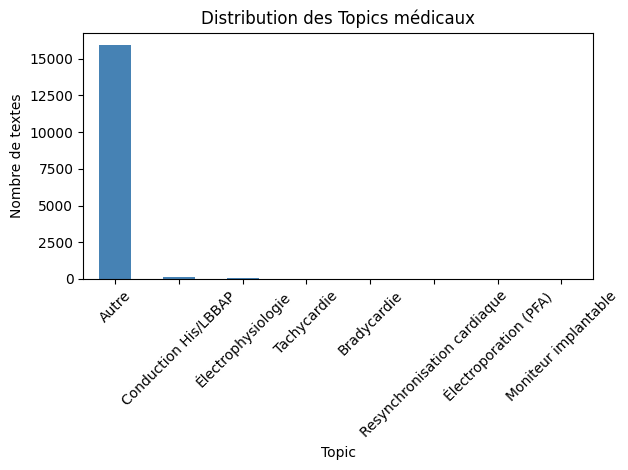

✅ Graphique sauvegardé !


In [ ]:
import matplotlib.pyplot as plt

df['topic'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution des Topics médicaux")
plt.xlabel("Topic")
plt.ylabel("Nombre de textes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("distribution_topics.png")
plt.show()
print("✅ Graphique sauvegardé !")


## 9. 🏷️ Suggestion automatique de #tags


In [ ]:
def suggerer_hashtags(texte):
    """Extrait les entités médicales comme #tags via spaCy + mots-clés"""
    
    # Entités détectées par spaCy
    doc = nlp_spacy(texte)
    hashtags = []
    
    # Ajouter les maladies/symptômes détectés par NER
    for ent in doc.ents:
        if ent.label_ in ["Disease", "Symptom", "MedicalProcedure"]:
            tag = "#" + ent.text.replace(" ", "_").lower()
            hashtags.append(tag)
    
    # Ajouter le Topic comme #tag
    topic = classifier_topic(texte)
    if topic != "Others":
        hashtags.append(f"#{topic}")
    
    # Ajouter les mots-clés médicaux trouvés dans le texte
    mots_medicaux = [
        "pacemaker", "défibrillateur", "ablation", "arythmie",
        "fibrillation", "tachycardie", "bradycardie", "insuffisance cardiaque",
        "stimulateur", "cathéter", "holter", "syncope"
    ]
    for mot in mots_medicaux:
        if mot in texte.lower():
            hashtags.append(f"#{mot.replace(' ', '_')}")
    
    return list(set(hashtags)) if hashtags else ["#médecine_générale"]

# Tester sur un cas rythmologique réel
post_test = "Patient de 72 ans avec BAV du 3ème degré, implantation pacemaker LBBAP, insuffisance cardiaque."
print("🏷️ #tags :", suggerer_hashtags(post_test))


🏷️ #tags : ['#Bradycardie', '#pacemaker', '#insuffisance_cardiaque']


## 10. 🔘 Simulation du bouton "Pré-soumettre"


In [ ]:
def generer_resume(texte_anon):
    lignes = [l.strip() for l in texte_anon.strip().split('\n') if l.strip()]
    
    indication, procedure, resultat, antecedents = "", "", "", ""
    
    for ligne in lignes:
        l = ligne.lower()
        
        if any(mot in l for mot in ['bav', 'fibrillation', 'tachycardie', 'bloc', 'fa ', 'porteur']):
            if not indication:
                indication = ligne
        
        if any(mot in l for mot in ['implantation', 'ablation', 'cardioversion', 'pacemaker', 'défibrillateur', 'crt', 'lbbap']):
            procedure = ligne
        
        if any(mot in l for mot in ['complication', 'succès', 'résultat', 'suivi', 'sortie', 'sans']):
            resultat = ligne
        
        if any(mot in l for mot in ['antécédents', 'antecedents', 'atcd', 'terrain']):
            antecedents = ligne
    
    resume = ""
    if indication  : resume += f"📌 Indication  : {indication}\n"
    if antecedents :
        contenu = re.sub(r'^antécédents\s*:\s*', '', antecedents, flags=re.IGNORECASE).strip()
        resume += f"🩺 Antécédents : {contenu}\n"
    if procedure   : resume += f"🔧 Procédure   : {procedure}\n"
    if resultat    : resume += f"✅ Résultat    : {resultat}\n"
    
    return resume if resume else texte_anon[:200] + "..."


In [ ]:
def generer_titre(texte_anon):
    """Génère un titre médical pertinent"""
    
    topic = classifier_topic(texte_anon)
    
    # Extraire l'âge
    age = ""
    age_match = re.search(r'(\d+)\s*ans', texte_anon)
    if age_match:
        age = f"Patient de {age_match.group(1)} ans"
    
    # Extraire la procédure principale
    procedures = {
        "pacemaker"     : "implantation de pacemaker",
        "défibrillateur": "implantation de défibrillateur",
        "ablation"      : "procédure d'ablation",
        "LBBAP"         : "implantation LBBAP",
        "CRT"           : "resynchronisation cardiaque",
    }
    procedure = ""
    for mot, description in procedures.items():
        if mot.lower() in texte_anon.lower():
            procedure = description
            break
    
    # Construire le titre
    if age and procedure:
        return f"{age} — {procedure} ({topic})"
    elif procedure:
        return f"Cas clinique : {procedure} ({topic})"
    elif age:
        return f"{age} — Cas {topic}"
    else:
        return f"Cas clinique rythmologique — {topic}"


def pre_soumettre(texte_brut):
    print("⏳ L'IA analyse votre post...\n")
    print("="*60)
    
    texte_anon = anonymiser(texte_brut)
    print("🔒 TEXTE ANONYMISÉ :")
    print(texte_anon)
    
    topic = classifier_topic(texte_anon)
    print(f"\n📂 TOPIC SUGGÉRÉ : {topic}")
    
    tags = suggerer_hashtags(texte_anon)
    print(f"\n🏷️  #TAGS SUGGÉRÉS : {tags}")
    
    titre = generer_titre(texte_anon)
    print(f"\n📝 TITRE SUGGÉRÉ : {titre}")
    
    resume = generer_resume(texte_anon)
    print(f"\n📋 RÉSUMÉ : {resume}")
   # Envoi vers la BDD
    envoyer_vers_api(
        titre            = titre,
        resume           = resume,
        content          = texte_brut + "\n" + " ".join(tags),
        content_anonymise= texte_anon + "\n" + " ".join(tags),
        topic            = topic,
        hashtags         = " ".join(tags),
        completude       = len(verifier_completude(texte_brut)) == 0
    )

    
    print("\n" + "="*60)
    print("✅ Vérifiez et cliquez sur Soumettre !")

# Test
print("🔒 Texte anonymisé :")
print(anonymiser(texte))

⏳ L'IA analyse votre post...

🔒 TEXTE ANONYMISÉ :

Patient de 72 ans, [PATIENT], né le [DATE].
Porteur d'un BAV du 3ème degré.
Implantation d'un pacemaker LBBAP le [DATE].
Antécédents : insuffisance cardiaque, HTA.
Procédure réalisée sans complication.


📂 TOPIC SUGGÉRÉ : Bradycardie

🏷️  #TAGS SUGGÉRÉS : ['#Bradycardie', '#pacemaker', '#insuffisance_cardiaque']

📝 TITRE SUGGÉRÉ : Patient de 72 ans — implantation de pacemaker (Bradycardie)

📋 RÉSUMÉ : 📌 Indication  : Porteur d'un BAV du 3ème degré.
🩺 Antécédents : insuffisance cardiaque, HTA.
🔧 Procédure   : Implantation d'un pacemaker LBBAP le [DATE].
✅ Résultat    : Procédure réalisée sans complication.


✅ Vérifiez et cliquez sur Soumettre !


##  Enrichissement des dictionnaires 
Ajout des topics rythmologiques (Brady, Tachy, CRT, EP, ICM, PFA, CSP) et des hashtags associés.

In [ ]:
# ============================================================
#  DICTIONNAIRE TOPICS RYTHMOLOGIQUES
#  Brady, Tachy, CRT, EP, ICM, PFA, CSP
# ============================================================

topics_keywords = {
    "Brady": [
        "bradycardie", "bradyarythmie",
        "bloc auriculo-ventriculaire", "BAV", "BAV 1", "BAV 2", "BAV 3",
        "bloc de branche", "dysfonction sinusale", "maladie de l'oreillette",
        "pause sinusale", "stimulateur cardiaque", "pacemaker", "PM",
        "implantation pacemaker", "sonde de stimulation",
        "inappropriate shock", "IAS", "S-ICD", "SICD", "CIED",
        "defibrillator", "sense-B", "Boston Scientific"
    ],
    "Tachy": [
        "tachycardie", "tachyarythmie",
        "fibrillation auriculaire", "FA", "flutter auriculaire",
        "tachycardie supraventriculaire", "TSV",
        "tachycardie ventriculaire", "TV", "fibrillation ventriculaire", "FV",
        "wolff-parkinson-white", "WPW", "syndrome de Brugada",
        "torsades de pointes",
        "atrial fibrillation", "AF", "persistent AF", "paroxysmal AF",
        "atrial flutter", "AFL", "VF storm", "VF", "PVC",
        "burst pacing", "non-inducibility", "sinus rhythm",
        "pulmonary vein isolation", "PVI", "redo ablation"
    ],
    "CRT": [
        "resynchronisation cardiaque", "CRT", "CRT-P", "CRT-D",
        "défibrillateur biventriculaire", "biventriculaire",
        "insuffisance cardiaque avancée", "FEVG basse",
        "sonde ventriculaire gauche", "sinus coronaire",
        "LVEF", "heart failure", "cardiac resynchronization"
    ],
    "EP": [
        "électrophysiologie", "exploration électrophysiologique", "EEP",
        "ablation", "ablation par radiofréquence", "ablation par cathéter",
        "mapping", "cartographie", "cathéter",
        "isolation des veines pulmonaires", "IVP",
        "ablation flutter", "ablation FA", "ablation TV",
        "electrophysiology", "catheter ablation", "radiofrequency",
        "RF ablation", "high density mapping", "HD Grid", "EnSite X",
        "EnsiteX", "CARTO", "Rhythmia", "Volta", "AF Explorer",
        "AFXplorer", "Sphere9", "Affera", "InHeart",
        "dispersion mapping", "substrate mapping", "LAT map",
        "skin to skin", "first pass efficacy", "bi-atrial mapping",
        "biatrial mapping", "Smart Segmentation", "autotagging",
        "Purkinje", "fascicular", "VT ablation", "VT storm",
        "NICM", "epicardial", "transseptal", "Impella",
        "protected VT", "PAINESD"
    ],
    "ICM": [
        "moniteur cardiaque implantable", "ICM", "Holter implantable",
        "Reveal", "enregistreur cardiaque", "monitoring longue durée",
        "détection arythmie", "bilan syncope", "syncope inexpliquée",
        "implantable cardiac monitor", "long term monitoring"
    ],
    "PFA": [
        "électroporation", "PFA", "pulsed field ablation",
        "champ électrique pulsé", "ablation par champ pulsé",
        "FARAPULSE", "ablation non thermique",
        "Varipulse", "VARIPULSE", "PulseSelect", "pulsed field",
        "non thermal ablation", "dual energy", "sphere 9"
    ],
    "CSP": [
        "conduction His", "pacing His", "His bundle pacing",
        "LBBAP", "left bundle branch area pacing",
        "pacing septal gauche", "stimulation physiologique",
        "His-Purkinje", "branche gauche",
        "conduction system pacing", "CSP", "LBBP",
        "left bundle branch pacing", "LBB pacer",
        "Abbott Locator Sheath", "UltiPace", "Biotronik",
        "Solia CSP", "SoliaCSP", "CPS Locator",
        "bundle branch block", "QRS narrowing",
        "intermittent AVB", "septal fibrosis"
    ]
}

print("✅ Dictionnaire topics_keywords enrichi !")
for topic, kws in topics_keywords.items():
    print(f"  → {topic} : {len(kws)} mots-clés")

✅ Dictionnaire topics_keywords enrichi !
  → Brady : 24 mots-clés
  → Tachy : 30 mots-clés
  → CRT : 13 mots-clés
  → EP : 49 mots-clés
  → ICM : 11 mots-clés
  → PFA : 14 mots-clés
  → CSP : 24 mots-clés


In [ ]:
# Termes anglais par topic (pour détection bilingue FR/EN)
topics_keywords_en = {
    "Brady" : ["bradycardia", "pacemaker", "av block", "lbbap", "lbbp",
               "sick sinus", "bundle branch block", "his bundle",
               "conduction system pacing"],
    "Tachy" : ["atrial fibrillation", "af", "flutter", "svt", "ablation",
               "pvi", "pulmonary vein isolation", "cardioversion",
               "ventricular tachycardia", "vt"],
    "CRT"   : ["cardiac resynchronization", "crt", "biventricular",
               "heart failure", "lvef", "ejection fraction", "crt-d"],
    "EP"    : ["electrophysiology", "mapping", "catheter ablation", "carto",
               "ensitex", "substrate", "arrhythmia", "radiofrequency"],
    "ICM"   : ["holter", "implantable monitor", "icm", "syncope",
               "loop recorder", "long term monitoring"],
    "PFA"   : ["pulsed field ablation", "pfa", "electroporation",
               "varipulse", "farapulse", "pulseselect", "non thermal"],
    "CSP"   : ["conduction system", "lbbap", "his bundle pacing",
               "left bundle branch", "lbbp", "physiological pacing"],
}

# Fusionner FR et EN dans topics_keywords
for topic, kws in topics_keywords_en.items():
    if topic in topics_keywords:
        topics_keywords[topic].extend(kws)

print("Dictionnaire enrichi en anglais !")
for topic, kws in topics_keywords.items():
    print(f"  → {topic} : {len(kws)} mots-clés")

In [ ]:
# ============================================================
#  DICTIONNAIRE HASHTAGS RYTHMOLOGIQUES
# ============================================================

hashtags_keywords = {
    "Brady": [
        "#bradycardie", "#pacemaker", "#BAV", "#stimulateurCardiaque",
        "#blocDebranche", "#dysfonctionSinusale",
        "#SICD", "#CIED", "#defibrillator", "#IAS"
    ],
    "Tachy": [
        "#tachycardie", "#fibrillatonAuriculaire", "#FA", "#flutter",
        "#TSV", "#tachycardieVentriculaire", "#WPW", "#Brugada",
        "#AF", "#AtrialFibrillation", "#AFL", "#PVI",
        "#VFStorm", "#PVC", "#redoAblation"
    ],
    "CRT": [
        "#CRT", "#resynchronisation", "#CRTd", "#CRTp",
        "#biventriculaire", "#insuffisanceCardiaque",
        "#heartFailure", "#LVEF", "#cardiacResynchronization"
    ],
    "EP": [
        "#ablation", "#electrophysiologie", "#mapping", "#catheter",
        "#isolationVeinesPulmonaires", "#ablationFA", "#ablationTV",
        "#electrophysiology", "#catheterAblation", "#RFablation",
        "#HDmapping", "#HDGrid", "#EnSiteX", "#CARTO",
        "#Volta", "#AFXplorer", "#Sphere9", "#Affera", "#InHeart",
        "#dispersionMapping", "#substrateMapping",
        "#biAtrialMapping", "#SmartSegmentation",
        "#VTablation", "#protectedVT", "#Purkinje",
        "#Impella", "#NICM", "#tailoredAblation"
    ],
    "ICM": [
        "#moniteurImplantable", "#ICM", "#HolterImplantable",
        "#syncope", "#monitoringCardiaque",
        "#implantableCardiacMonitor", "#longTermMonitoring"
    ],
    "PFA": [
        "#PFA", "#electroporation", "#pulsedFieldAblation",
        "#ablationNonThermique", "#FARAPULSE",
        "#Varipulse", "#PulseSelect", "#dualEnergy"
    ],
    "CSP": [
        "#LBBAP", "#HisPacing", "#stimulationPhysiologique",
        "#conductionHis", "#brancheGauche",
        "#CSP", "#LBBP", "#conductionSystemPacing",
        "#Biotronik", "#SoliaCSP", "#AbbottLocator",
        "#QRSnarrowing"
    ]
}

print("✅ Dictionnaire hashtags_keywords enrichi !")
for topic, tags in hashtags_keywords.items():
    print(f"  → {topic} : {len(tags)} hashtags")

✅ Dictionnaire hashtags_keywords enrichi !
  → Brady : 10 hashtags
  → Tachy : 15 hashtags
  → CRT : 9 hashtags
  → EP : 29 hashtags
  → ICM : 7 hashtags
  → PFA : 8 hashtags
  → CSP : 12 hashtags


##  Fonction verifier_completude() 
Vérifie qu'un post médical contient bien : âge, sexe, antécédents, durée procédure, matériel utilisé.

In [ ]:

import re
# ============================================================
#  FONCTION verifier_completude()
# ============================================================

def verifier_completude(texte: str) -> dict:
    """
    Vérifie qu'un post médical contient les informations essentielles.
    Retourne un dict avec le statut de chaque champ et les alertes.
    """
    texte_lower = texte.lower()
    alertes = []
    resultats = {}

    # --- ÂGE ---
    age_patterns = [
        r'\b\d{1,3}\s*ans\b',
        r'\bage\s*:\s*\d+',
        r'\bpatient de \d+',
        r'\b\d{1,3}[-\s]year[s]?[-\s]old\b'
    ]
    age_trouve = any(re.search(p, texte_lower) for p in age_patterns)
    resultats["age"] = age_trouve
    if not age_trouve:
        alertes.append("⚠️ Âge du patient manquant")

    # --- SEXE ---
    sexe_patterns = [
        r'\b(homme|femme|masculin|féminin|male|female)\b',
        r'\b(mr|mme|monsieur|madame)\b',
        r'\b(il|elle) (présente|consulte|est)\b',
        r'\b(patient|patiente)\b'
    ]
    sexe_trouve = any(re.search(p, texte_lower) for p in sexe_patterns)
    resultats["sexe"] = sexe_trouve
    if not sexe_trouve:
        alertes.append("⚠️ Sexe du patient manquant")

    # --- ANTÉCÉDENTS ---
    antecedents_patterns = [
        r'\bantécédents?\b',
        r'\bATCD\b',
        r'\bhistoire médicale\b',
        r'\bdiagnostiqué\b',
        r'\bconnu pour\b',
        r'\bhistory of\b'
    ]
    atcd_trouve = any(re.search(p, texte_lower) for p in antecedents_patterns)
    resultats["antecedents"] = atcd_trouve
    if not atcd_trouve:
        alertes.append("⚠️ Antécédents médicaux manquants")

    # --- DURÉE PROCÉDURE ---
    duree_patterns = [
        r'\b\d+\s*(min|minutes?|heures?|h)\b',
        r'\bdurée\s*:\s*\d+',
        r'\bprocédure de \d+',
        r'\bduring \d+\s*(min|hour)'
    ]
    duree_trouve = any(re.search(p, texte_lower) for p in duree_patterns)
    resultats["duree_procedure"] = duree_trouve
    if not duree_trouve:
        alertes.append("⚠️ Durée de la procédure manquante")

    # --- MATÉRIEL UTILISÉ ---
    materiel_patterns = [
        r'\b(cathéter|sonde|défibrillateur|pacemaker|stimulateur|électrode)\b',
        r'\b(FARAPULSE|PentaRay|ThermoCool|Rhythmia|Carto|EnSite)\b',
        r'\b(système de mapping|console|générateur)\b',
        r'\bmatériel\s*:',
        r'\butilisé\s*:'
    ]
    materiel_trouve = any(re.search(p, texte_lower) for p in materiel_patterns)
    resultats["materiel"] = materiel_trouve
    if not materiel_trouve:
        alertes.append("⚠️ Matériel utilisé non mentionné")

    # --- RÉSUMÉ ---
    complet = len(alertes) == 0
    return {
        "complet": complet,
        "champs": resultats,
        "alertes": alertes
    }


# --- TESTS ---
post_complet = """
Patient de 67 ans, homme, antécédents de fibrillation auriculaire et d'hypertension.
Ablation par radiofréquence réalisée avec cathéter ThermoCool.
Durée de la procédure : 95 minutes. Résultat : succès.
"""

post_incomplet = """
Ablation FA réalisée avec succès. Pas de complications.
"""

print("=" * 50)
print("TEST 1 — Post complet")
print("=" * 50)
r1 = verifier_completude(post_complet)
print(f"Complet : {r1['complet']}")
print(f"Champs  : {r1['champs']}")
if r1['alertes']:
    for a in r1['alertes']: print(a)
else:
    print("✅ Toutes les informations sont présentes !")

print()
print("=" * 50)
print("TEST 2 — Post incomplet")
print("=" * 50)
r2 = verifier_completude(post_incomplet)
print(f"Complet : {r2['complet']}")
for a in r2['alertes']:
    print(a)

TEST 1 — Post complet
Complet : True
Champs  : {'age': True, 'sexe': True, 'antecedents': True, 'duree_procedure': True, 'materiel': True}
✅ Toutes les informations sont présentes !

TEST 2 — Post incomplet
Complet : False
⚠️ Âge du patient manquant
⚠️ Sexe du patient manquant
⚠️ Antécédents médicaux manquants
⚠️ Durée de la procédure manquante
⚠️ Matériel utilisé non mentionné


##  Trends par tag 
Calcule les points par tag selon les réactions : Extremely useful = 3pts, Useful = 1pt.

In [ ]:
# ============================================================
#  TRENDS PAR TAG — Partie 2 CDC
#  Extremely useful = 3pts | Useful = 1pt
# ============================================================

def calculer_trends(posts: list) -> dict:
    """
    Calcule les points par tag selon les réactions.
    
    Chaque post doit être un dict avec :
      - 'tags'             : list de tags (ex: ['#ablation', '#FA'])
      - 'extremely_useful' : int (nombre de réactions 'Extremely useful')
      - 'useful'           : int (nombre de réactions 'Useful')
    
    Retourne un dict {tag: points} trié par score décroissant.
    """
    scores = {}

    for post in posts:
        points = (post.get("extremely_useful", 0) * 3) + (post.get("useful", 0) * 1)
        for tag in post.get("tags", []):
            scores[tag] = scores.get(tag, 0) + points

    # Trier par score décroissant
    scores_tries = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))
    return scores_tries


def afficher_trends(scores: dict, top_n: int = 10):
    """Affiche le classement des tags les plus utiles."""
    print(f"\n🏆 TOP {top_n} TAGS LES PLUS UTILES")
    print("-" * 40)
    for i, (tag, pts) in enumerate(list(scores.items())[:top_n], 1):
        barre = "█" * min(pts, 30)
        print(f"  {i:2}. {tag:<30} {pts:4} pts  {barre}")


# --- DONNÉES DE TEST ---
posts_exemple = [
    {
        "tags": ["#ablation", "#FA", "#electrophysiologie"],
        "extremely_useful": 5,
        "useful": 3
    },
    {
        "tags": ["#pacemaker", "#bradycardie", "#BAV"],
        "extremely_useful": 2,
        "useful": 8
    },
    {
        "tags": ["#ablation", "#PFA", "#electrophysiologie"],
        "extremely_useful": 10,
        "useful": 2
    },
    {
        "tags": ["#CRT", "#resynchronisation", "#insuffisanceCardiaque"],
        "extremely_useful": 1,
        "useful": 4
    },
    {
        "tags": ["#LBBAP", "#stimulationPhysiologique", "#pacemaker"],
        "extremely_useful": 4,
        "useful": 6
    },
    {
        "tags": ["#ICM", "#syncope", "#monitoringCardiaque"],
        "extremely_useful": 0,
        "useful": 5
    }
]

scores = calculer_trends(posts_exemple)
afficher_trends(scores, top_n=10)


🏆 TOP 10 TAGS LES PLUS UTILES
----------------------------------------
   1. #ablation                        50 pts  ██████████████████████████████
   2. #electrophysiologie              50 pts  ██████████████████████████████
   3. #pacemaker                       32 pts  ██████████████████████████████
   4. #PFA                             32 pts  ██████████████████████████████
   5. #FA                              18 pts  ██████████████████
   6. #LBBAP                           18 pts  ██████████████████
   7. #stimulationPhysiologique        18 pts  ██████████████████
   8. #bradycardie                     14 pts  ██████████████
   9. #BAV                             14 pts  ██████████████
  10. #CRT                              7 pts  ███████


##  Visualisation des trends 
Graphique matplotlib du TOP 10 des tags les plus utiles.

C:\Users\marie\AppData\Local\Temp\ipykernel_13360\3807989067.py:43: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\marie\AppData\Local\Temp\ipykernel_13360\3807989067.py:44: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("trends_top10.png", dpi=150, bbox_inches="tight")
C:\Users\marie\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


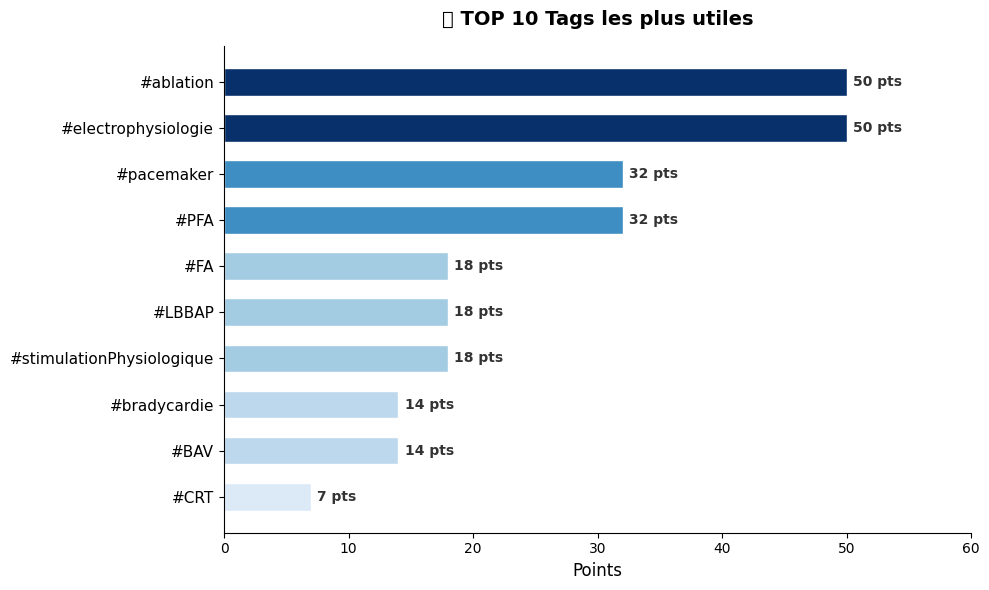

✅ Graphique sauvegardé : trends_top10.png


In [ ]:
# ============================================================
#  VISUALISATION DES TRENDS — matplotlib
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualiser_trends(scores: dict, top_n: int = 10):
    """
    Affiche un graphique bar horizontal du TOP N des tags les plus utiles.
    """
    # Prendre le top N
    top_tags = list(scores.items())[:top_n]
    tags = [t[0] for t in top_tags]
    points = [t[1] for t in top_tags]

    # Couleurs dégradées selon le score
    couleurs = plt.cm.Blues([p / max(points) for p in points])

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.barh(tags[::-1], points[::-1], color=couleurs[::-1], edgecolor="white", height=0.6)

    # Ajouter les valeurs sur les barres
    for bar, pt in zip(bars, points[::-1]):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{pt} pts",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#333333"
        )

    ax.set_xlabel("Points", fontsize=12)
    ax.set_title("🏆 TOP 10 Tags les plus utiles", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlim(0, max(points) * 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=11)

    plt.tight_layout()
    plt.savefig("trends_top10.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Graphique sauvegardé : trends_top10.png")


# --- Utiliser les scores calculés précédemment ---
visualiser_trends(scores, top_n=10)

##  Détection automatique du topic et génération de hashtags — 

In [ ]:
# ============================================================
#  FONCTION detecter_topic()
#  Détecte automatiquement le topic d'un texte médical
#  en cherchant dans topics_keywords
# ============================================================

def detecter_topic(texte: str) -> str:
    """
    Retourne le topic le plus probable pour un texte médical.
    Cherche les mots-clés de chaque topic dans le texte.
    Retourne "Autre" si aucun topic n'est détecté.
    """
    texte_lower = texte.lower()
    scores_topics = {}

    for topic, keywords in topics_keywords.items():
        score = sum(1 for kw in keywords if kw.lower() in texte_lower)
        if score > 0:
            scores_topics[topic] = score

    if not scores_topics:
        return "Autre"

    # Retourne le topic avec le plus de mots-clés trouvés
    return max(scores_topics, key=scores_topics.get)


# --- TESTS ---
textes_test = [
    "Patient implanté avec un pacemaker suite à un BAV complet. Dysfonction sinusale confirmée.",
    "Ablation de flutter auriculaire réalisée avec cathéter et mapping électrophysiologique.",
    "Pose d'un ICM Reveal pour bilan de syncope inexpliquée, monitoring longue durée prévu.",
    "Procédure PFA avec FARAPULSE, ablation non thermique de la fibrillation auriculaire.",
    "Implantation CRT-D pour resynchronisation cardiaque, FEVG basse à 25%.",
    "Stimulation physiologique LBBAP, pacing His-Purkinje sur branche gauche."
]

print("🔍 DÉTECTION DE TOPICS")
print("-" * 50)
for texte_t in textes_test:
    topic = detecter_topic(texte_t)
    print(f"  → [{topic}] {texte_t[:60]}...")

🔍 DÉTECTION DE TOPICS
--------------------------------------------------
  → [Brady] Patient implanté avec un pacemaker suite à un BAV complet. D...
  → [EP] Ablation de flutter auriculaire réalisée avec cathéter et ma...
  → [ICM] Pose d'un ICM Reveal pour bilan de syncope inexpliquée, moni...
  → [PFA] Procédure PFA avec FARAPULSE, ablation non thermique de la f...
  → [CRT] Implantation CRT-D pour resynchronisation cardiaque, FEVG ba...
  → [CSP] Stimulation physiologique LBBAP, pacing His-Purkinje sur bra...


In [ ]:
# ============================================================
#  FONCTION generer_hashtags_depuis_topic()
#  Génère automatiquement les hashtags depuis le topic détecté
# ============================================================

def generer_hashtags_depuis_topic(texte: str) -> dict:
    """
    Détecte le topic d'un texte puis retourne les hashtags associés.
    Retourne un dict avec le topic détecté et les hashtags.
    """
    topic = detecter_topic(texte)
    
    if topic == "Autre":
        return {
            "topic": "Autre",
            "hashtags": []
        }
    
    hashtags = hashtags_keywords.get(topic, [])
    
    return {
        "topic": topic,
        "hashtags": hashtags
    }


# --- TESTS ---
textes_test = [
    "Patient implanté avec un pacemaker suite à un BAV complet.",
    "Ablation de flutter auriculaire avec cathéter et mapping.",
    "Pose d'un ICM Reveal pour bilan de syncope inexpliquée.",
    "Procédure PFA avec FARAPULSE sur fibrillation auriculaire.",
    "Implantation CRT-D pour resynchronisation cardiaque.",
    "Stimulation physiologique LBBAP sur branche gauche."
]

print("🏷️ GÉNÉRATION DE HASHTAGS DEPUIS TOPIC")
print("-" * 50)
for texte_t in textes_test:
    result = generer_hashtags_depuis_topic(texte_t)
    print(f"\n  Texte   : {texte_t[:55]}...")
    print(f"  Topic   : {result['topic']}")
    print(f"  Hashtags: {result['hashtags']}")

🏷️ GÉNÉRATION DE HASHTAGS DEPUIS TOPIC
--------------------------------------------------

  Texte   : Patient implanté avec un pacemaker suite à un BAV compl...
  Topic   : Brady
  Hashtags: ['#bradycardie', '#pacemaker', '#BAV', '#stimulateurCardiaque', '#blocDebranche', '#dysfonctionSinusale', '#SICD', '#CIED', '#defibrillator', '#IAS']

  Texte   : Ablation de flutter auriculaire avec cathéter et mappin...
  Topic   : EP
  Hashtags: ['#ablation', '#electrophysiologie', '#mapping', '#catheter', '#isolationVeinesPulmonaires', '#ablationFA', '#ablationTV', '#electrophysiology', '#catheterAblation', '#RFablation', '#HDmapping', '#HDGrid', '#EnSiteX', '#CARTO', '#Volta', '#AFXplorer', '#Sphere9', '#Affera', '#InHeart', '#dispersionMapping', '#substrateMapping', '#biAtrialMapping', '#SmartSegmentation', '#VTablation', '#protectedVT', '#Purkinje', '#Impella', '#NICM', '#tailoredAblation']

  Texte   : Pose d'un ICM Reveal pour bilan de syncope inexpliquée....
  Topic   : ICM
  Hashtags: [

## 📊 Trends en variation (dérivée première) 
Calcule la variation en % des scores par tag selon l'unité de temps choisie (heure/jour/semaine/mois).

In [ ]:
# ============================================================
#  TRENDS EN VARIATION — Dérivée première
#  Variation en % par unité de temps (heure/jour/semaine/mois)
# ============================================================

from datetime import datetime

def calculer_trends_variation(posts: list, unite: str = "jour") -> dict:
    """
    Calcule les scores par tag ET leur variation en % selon l'unité de temps.
    
    Chaque post doit contenir :
      - 'tags'             : list de tags
      - 'extremely_useful' : int
      - 'useful'           : int
      - 'date'             : datetime object
    
    unite : 'heure' | 'jour' | 'semaine' | 'mois'
    
    Retourne un dict {tag: {'score': int, 'variation': float}} trié par score décroissant.
    """
    # Définir la période courante et précédente
    now = datetime.now()

    def get_periode(dt: datetime) -> int:
        if unite == "heure":
            return dt.hour + dt.day * 24
        elif unite == "jour":
            return dt.timetuple().tm_yday
        elif unite == "semaine":
            return dt.isocalendar()[1]
        elif unite == "mois":
            return dt.month
        return dt.timetuple().tm_yday

    periode_actuelle = get_periode(now)

    scores_actuels = {}
    scores_precedents = {}

    for post in posts:
        points = (post.get("extremely_useful", 0) * 3) + (post.get("useful", 0) * 1)
        periode_post = get_periode(post.get("date", now))

        for tag in post.get("tags", []):
            if periode_post == periode_actuelle:
                scores_actuels[tag] = scores_actuels.get(tag, 0) + points
            elif periode_post == periode_actuelle - 1:
                scores_precedents[tag] = scores_precedents.get(tag, 0) + points

    # Calculer la variation en %
    resultats = {}
    tous_tags = set(list(scores_actuels.keys()) + list(scores_precedents.keys()))

    for tag in tous_tags:
        score_actuel = scores_actuels.get(tag, 0)
        score_precedent = scores_precedents.get(tag, 0)

        if score_precedent == 0:
            variation = 100.0 if score_actuel > 0 else 0.0
        else:
            variation = ((score_actuel - score_precedent) / score_precedent) * 100

        resultats[tag] = {
            "score": score_actuel,
            "variation": round(variation, 1)
        }

    # Trier par score décroissant
    resultats = dict(sorted(resultats.items(), key=lambda x: x[1]["score"], reverse=True))
    return resultats


def afficher_trends_variation(resultats: dict, top_n: int = 10):
    """Affiche le classement avec score et variation."""
    print(f"\n🏆 TOP {top_n} TAGS — Score + Variation")
    print("-" * 55)
    for i, (tag, data) in enumerate(list(resultats.items())[:top_n], 1):
        variation = data["variation"]
        fleche = "↑" if variation > 0 else ("↓" if variation < 0 else "→")
        couleur = "+" if variation > 0 else ""
        print(f"  {i:2}. {tag:<30} {data['score']:4} pts  {fleche} {couleur}{variation}%")


# --- DONNÉES DE TEST avec dates ---
from datetime import timedelta

today = datetime.now()
yesterday = today - timedelta(days=1)

posts_avec_dates = [
    {"tags": ["#ablation", "#FA", "#electrophysiologie"], "extremely_useful": 5, "useful": 3, "date": today},
    {"tags": ["#ablation", "#PFA"], "extremely_useful": 10, "useful": 2, "date": today},
    {"tags": ["#pacemaker", "#bradycardie"], "extremely_useful": 2, "useful": 4, "date": today},
    {"tags": ["#ablation", "#FA"], "extremely_useful": 3, "useful": 1, "date": yesterday},
    {"tags": ["#pacemaker", "#BAV"], "extremely_useful": 5, "useful": 5, "date": yesterday},
    {"tags": ["#CRT", "#resynchronisation"], "extremely_useful": 1, "useful": 2, "date": yesterday},
]

resultats = calculer_trends_variation(posts_avec_dates, unite="jour")
afficher_trends_variation(resultats, top_n=10)


🏆 TOP 10 TAGS — Score + Variation
-------------------------------------------------------
   1. #ablation                        50 pts  ↑ +400.0%
   2. #PFA                             32 pts  ↑ +100.0%
   3. #electrophysiologie              18 pts  ↑ +100.0%
   4. #FA                              18 pts  ↑ +80.0%
   5. #bradycardie                     10 pts  ↑ +100.0%
   6. #pacemaker                       10 pts  ↓ -50.0%
   7. #resynchronisation                0 pts  ↓ -100.0%
   8. #BAV                              0 pts  ↓ -100.0%
   9. #CRT                              0 pts  ↓ -100.0%


## ✍️ Génération automatique du titre et du résumé 
Propose un titre (max 140 caractères) et un résumé "In a nutshell" (max 256 caractères) basés sur le texte du post.

In [ ]:
# ============================================================
#  FONCTIONS generer_titre() et generer_resume()
#  Titre : max 140 caractères
#  Résumé "In a nutshell" : max 256 caractères
# ============================================================

def generer_titre(texte: str) -> str:
    texte_lower = texte.lower()
    topic = detecter_topic(texte)

    # --- Extraire l'âge ---
    age = ""
    age_match = re.search(r'(\d{1,3})\s*[-]?\s*(ans|year|yo|y\.o)', texte_lower)
    if age_match:
        age = f" — {age_match.group(1)}yo"

    # --- Extraire la procédure principale ---
    procedures = {
        "Tailored Ablation"    : ["tailored", "substrate-based", "dispersion mapping", "smart segmentation"],
        "Redo Ablation"        : ["redo ablation", "redo", "recurrence", "récidive"],
        "PVI"                  : ["pulmonary vein isolation", "pvi", "isolation des veines pulmonaires"],
        "PFA"                  : ["pulsed field ablation", "pfa", "varipulse", "farapulse", "pulseselect", "électroporation"],
        "RF Ablation"          : ["radiofrequency", "rf ablation", "ablation par radiofréquence", "thermocool"],
        "VT Ablation"          : ["vt ablation", "ventricular tachycardia", "tachycardie ventriculaire", "vt storm"],
        "LBBAP Implantation"   : ["lbbap", "left bundle branch area pacing", "lbbp"],
        "His Pacing"           : ["his bundle pacing", "his pacing", "conduction his"],
        "CRT Implantation"     : ["crt-d", "crt-p", "resynchronisation", "cardiac resynchronization"],
        "ICM Insertion"        : ["icm", "holter implantable", "reveal", "implantable cardiac monitor"],
        "Pacemaker Implantation": ["pacemaker", "stimulateur cardiaque", "pm implant"],
        "ICD Implantation"     : ["icd", "defibrillator", "défibrillateur"],
        "Mapping"              : ["high density mapping", "hd mapping", "biatrial mapping", "substrate mapping"],
    }

    procedure_detectee = ""
    for procedure, keywords in procedures.items():
        if any(kw in texte_lower for kw in keywords):
            procedure_detectee = procedure
            break

    # --- Extraire la pathologie principale ---
    pathologies = {
        "Persistent AF" : ["persistent af", "persistent atrial fibrillation", "fa persistante", "fibrillation auriculaire persistante"],
        "Paroxysmal AF" : ["paroxysmal af", "fa paroxystique", "fibrillation auriculaire paroxystique"],
        "Atrial Flutter": ["flutter auriculaire", "atrial flutter", "afl"],
        "VF Storm"      : ["vf storm", "ventricular fibrillation storm"],
        "VT"            : ["ventricular tachycardia", "tachycardie ventriculaire"],
        "Brady"         : ["bradycardie", "bradycardia", "bav", "bloc auriculo"],
        "Heart Failure" : ["insuffisance cardiaque", "heart failure", "lvef"],
        "Syncope"       : ["syncope", "syncope inexpliquée"],
    }

    pathologie_detectee = ""
    for pathologie, keywords in pathologies.items():
        if any(kw in texte_lower for kw in keywords):
            pathologie_detectee = pathologie
            break

    # --- Construire le titre ---
    if procedure_detectee and pathologie_detectee:
        titre = f"{procedure_detectee} in {pathologie_detectee}{age}"
    elif procedure_detectee:
        titre = f"[{topic}] {procedure_detectee}{age}"
    elif pathologie_detectee:
        titre = f"[{topic}] Case — {pathologie_detectee}{age}"
    else:
        titre = f"[{topic}] Clinical Case in Rhythmology{age}"

    return titre[:140]


def generer_resume(texte: str, max_chars: int = 256) -> str:
    texte_propre = texte.strip().replace("\n", " ")
    texte_propre = re.sub(r'\s+', ' ', texte_propre)

    # Amélioration : gère aussi les sauts de ligne comme séparateurs
    phrases = re.split(r'(?<=[.!?])\s+|\n', texte_propre)
    phrases = [p.strip() for p in phrases if len(p.strip()) > 10]

    resume = ""
    for phrase in phrases:
        if len(resume) + len(phrase) + 1 <= max_chars:
            resume += phrase + " "
        else:
            break

    resume = resume.strip()
    if len(resume) > max_chars:
        resume = resume[:max_chars - 3] + "..."

    return resume


# --- TESTS avec les vrais posts LinkedIn ---
posts_test = [
    """63-year-old hypertensive patient with recurrences of atrial fibrillation,
    12 months after a first successful pulmonary vein isolation (PVI).
    Redo ablation performed with Abbott EnsiteX and Volta Medical AI software.""",

    """A case of PVI for patient with persistent Afib. Using Varipulse PFA catheter
    with the new VARIPULSE platform.""",

    """70-year-old male. LBBAP implantation decided. First complex CSP case using
    SoliaCSP Biotronik system. QRS narrowing of 60ms achieved.""",

    """58-year-old schoolteacher with heart failure following anterior MI (LVEF 20%)
    and VF storm. Targeted ablation of Purkinje network.""",

    """Patient de 72 ans, homme, fibrillation auriculaire persistante depuis 3 ans.
    Ablation par radiofréquence avec cathéter ThermoCool. Durée : 110 minutes.""",

    # Cas réel de Moti — à coller ici quand tu l'auras
    # """...""",
]

print("GENERATION AUTOMATIQUE — TITRE + RESUME")
print("=" * 60)
for post in posts_test:
    titre  = generer_titre(post)
    resume = generer_resume(post)
    print(f"\nTITRE ({len(titre)} caractères) :")
    print(f"   {titre}")
    print(f"\nRESUME ({len(resume)} caractères) :")
    print(f"   {resume}")
    print(f"\nTitre OK  : {len(titre) <= 140}")
    print(f"Resume OK : {len(resume) <= 256}")
    print("-" * 60)

GENERATION AUTOMATIQUE — TITRE + RESUME


NameError: name 'detecter_topic' is not defined

Connexion API 

In [ ]:
import requests

def envoyer_vers_api(titre, resume, content, content_anonymise,
                     topic, hashtags, completude):
    try:
        response = requests.post("http://localhost:3000/api/posts", json={
            "user_id":           1,
            "titre":             titre,
            "resume":            resume,
            "content":           content,
            "content_anonymise": content_anonymise,
            "topic":             topic,
            "hashtags":          hashtags,
            "language":          "fr",
            "status":            "brouillon",
            "completude":        completude
        })
        if response.status_code == 201:
            print(f"Post envoye en BDD ! ID : {response.json().get('id')}")
        else:
            print(f"Erreur API : {response.status_code}")
    except Exception as e:
        print(f"API non disponible : {e}")

## 🖥️ Interface interactive 
Formulaire ipywidgets pour tester le pipeline sur n'importe quel texte.

In [ ]:
# ============================================================
#  INTERFACE INTERACTIVE — ipywidgets
#  Formulaire pour tester le pipeline sur n'importe quel texte
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Zone de saisie du texte ---
texte_input = widgets.Textarea(
    value="",
    placeholder="Collez ici un post médical (cas patient, procédure...)",
    description="",
    layout=widgets.Layout(width="100%", height="150px")
)

# --- Bouton d'analyse ---
btn_analyser = widgets.Button(
    description="🔍 Analyser le post",
    button_style="primary",
    layout=widgets.Layout(width="200px", margin="10px 0")
)

# --- Zone de résultats ---
output = widgets.Output()

def analyser_post(b):
    with output:
        clear_output()
        texte = texte_input.value.strip()

        if not texte:
            print("⚠️ Veuillez saisir un texte à analyser.")
            return

        print("=" * 60)
        print("🔍 ANALYSE DU POST")
        print("=" * 60)

        # 1. Topic
        topic = detecter_topic(texte)
        print(f"\n🏷️  Topic détecté    : {topic}")

        # 2. Hashtags
        result_hashtags = generer_hashtags_depuis_topic(texte)
        print(f"#️⃣  Hashtags suggérés : {', '.join(result_hashtags['hashtags'][:5])}")

        # 3. Titre
        titre = generer_titre(texte)
        print(f"\n📌 Titre généré     : {titre}")
        print(f"   ({len(titre)} caractères — max 140) {'✅' if len(titre) <= 140 else '❌'}")

        # 4. Résumé
        resume = generer_resume(texte)
        print(f"\n📝 Résumé généré    :")
        print(f"   {resume}")
        print(f"   ({len(resume)} caractères — max 256) {'✅' if len(resume) <= 256 else '❌'}")

        # 5. Complétude
        completude = verifier_completude(texte)
        print(f"\n✅ Complétude       : {'Complet' if completude['complet'] else 'Incomplet'}")
        if completude["alertes"]:
            for alerte in completude["alertes"]:
                print(f"   {alerte}")
        else:
            print("   Toutes les informations sont présentes !")

        # 6. Anonymisation
        try:
            texte_anon = anonymiser(texte)
            print(f"\n🔒 Texte anonymisé  :")
            print(f"   {texte_anon[:200]}{'...' if len(texte_anon) > 200 else ''}")
        except Exception as e:
            print(f"\n🔒 Anonymisation : non disponible ({e})")

        print("=" * 60)

btn_analyser.on_click(analyser_post)

# --- Affichage ---
print("🖥️ INTERFACE INTERACTIVE — Pipeline IA Médical")
print("-" * 60)
display(texte_input, btn_analyser, output)

🖥️ INTERFACE INTERACTIVE — Pipeline IA Médical
------------------------------------------------------------


Textarea(value='', layout=Layout(height='150px', width='100%'), placeholder='Collez ici un post médical (cas p…

Button(button_style='primary', description='🔍 Analyser le post', layout=Layout(margin='10px 0', width='200px')…

Output()